### Imports

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import numpy as np
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

import sys
sys.path.insert(0, "..")

from model.data.load_data import LoadBaseSatelliteData
from vis_plotting.general_plotting import *


In [2]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Data loading

In [3]:
"""
Load the footprints for the region and period with the base data object.
Stores the footprints (without cropping) in data.fp_data_full
load_everything=True also loads the original meteorology, without cropping or interpolating, in data.met_file, as well as the topography and landuse in data.topog_file and data.landcover_file, which are interpolated in space to the shape of the footprints
"""
#data = LoadBaseSatelliteData(201601, region="BRAZIL", load_everything=True, verbose=True)
data = LoadBaseSatelliteData(201603, region="SAHARA", load_everything=True, verbose=True)

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/NORTHAFRICA/*SAHARA*NORTHAFRICA_201603*.nc
no sampling was done because you didnt pass a valid sampling mode, or freq=1
Loading 940 footprints

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/NORTHAFRICA/NORTHAFRICA_Met_201603*.nc

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!


## Jeff trying stuff out

### Plot map with bounding box for data

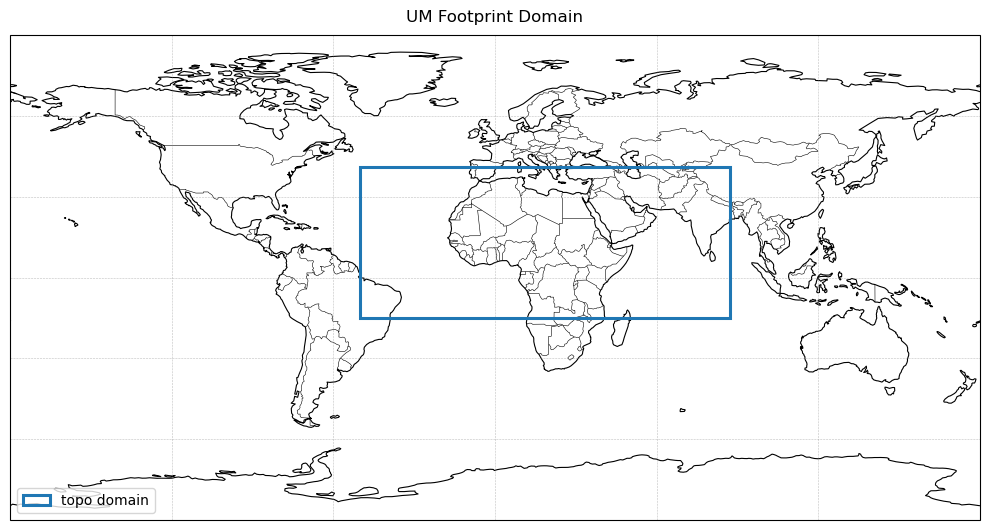

In [6]:
fig, ax = plot_domain(
    data, "topo",
    projection="PlateCarree",  # "PlateCarree" gives a true lon/lat view; "Robinson" for global context
    zoom_to_data=False,
    title="UM Footprint Domain"
)
plt.show()

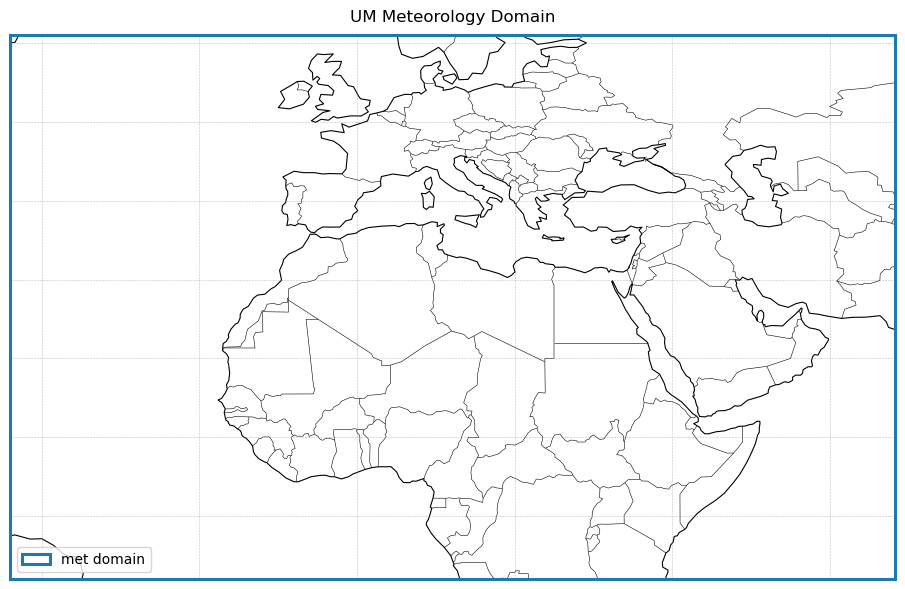

In [7]:
# Can also constrain to only showing the met domain
fig, ax = plot_domain(
    data, "met",
    projection="PlateCarree",  # "PlateCarree" gives a true lon/lat view; "Robinson" for global context
    zoom_to_data=True,
    title="UM Meteorology Domain"
)
plt.show()

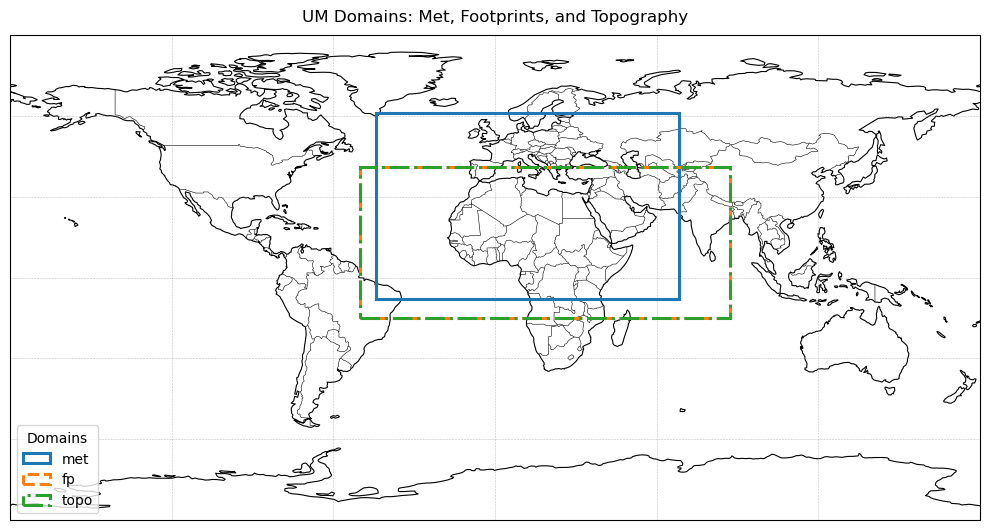

In [8]:
# Plot all three with distinct styles, zooming to the union of their extents
fig, ax = plot_multiple_data_series(
    data,
    show=("met", "fp", "topo"),
    colours={"met":"tab:blue", "fp":"tab:orange", "topo":"tab:green"},
    linestyles={"met":"-", "fp":"--", "topo":"-."},
    linewidths={"met":2.2, "fp":2.2, "topo":2.2},
    facealpha=0.0,                 # set to, e.g., 0.15 if you want light fills
    projection="PlateCarree",
    wrap_center=0,
    zoom_to_union=False,
    title="UM Domains: Met, Footprints, and Topography"
)
plt.show()

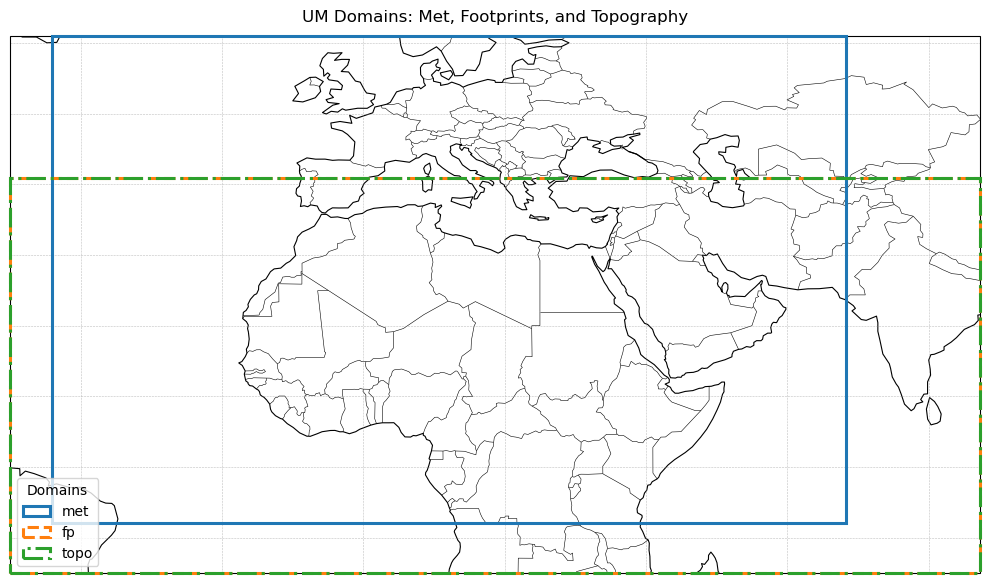

In [9]:
# Plot all three with distinct styles, zooming to the union of their extents
fig, ax = plot_multiple_data_series(
    data,
    show=("met", "fp", "topo"),
    colours={"met":"tab:blue", "fp":"tab:orange", "topo":"tab:green"},
    linestyles={"met":"-", "fp":"--", "topo":"-."},
    linewidths={"met":2.2, "fp":2.2, "topo":2.2},
    facealpha=0.0,                 # set to, e.g., 0.15 if you want light fills
    projection="PlateCarree",
    wrap_center=0,
    zoom_to_union=True,
    title="UM Domains: Met, Footprints, and Topography"
)
plt.show()

### Plot topo

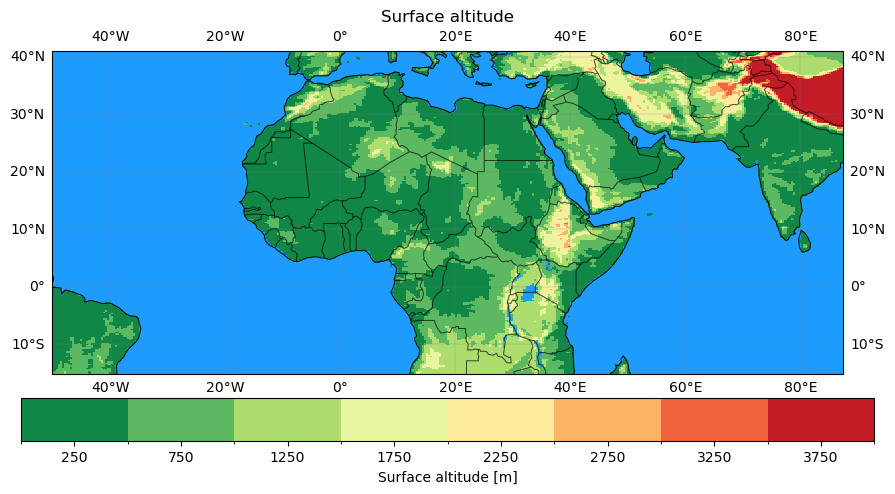

In [ ]:
fig, ax, mesh, edges = plot_topography(
    data,
    n_bins=8,
    vmin=0, vmax=4000, # Max altitude in metres
    plot_country_boundaries=True
)

### Histogram of topography

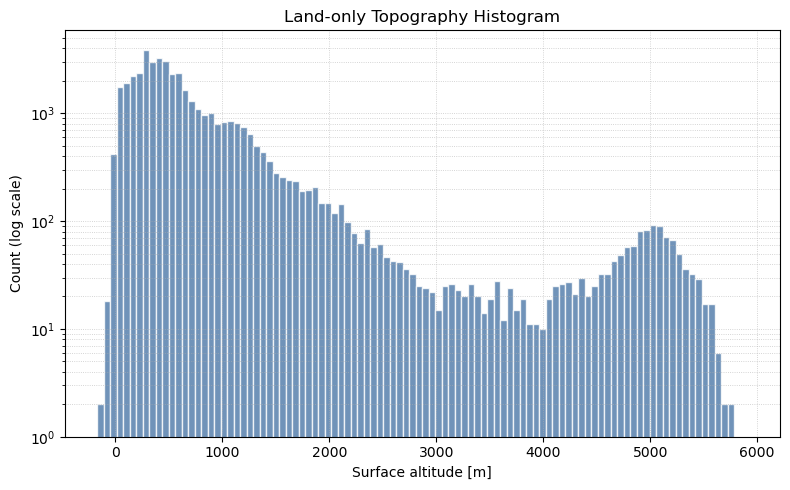

In [ ]:
fig, ax, _ = plot_topography_histogram(
    data,
    bins=100, #Or can be eg np.arange(-500, 6000, 100)
    log_y=True,
    density=False,
    title="Land-only Topography Histogram"
)

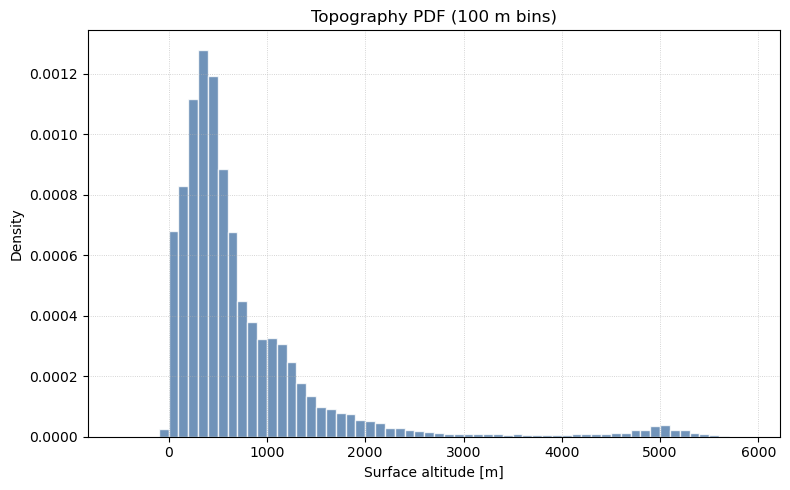

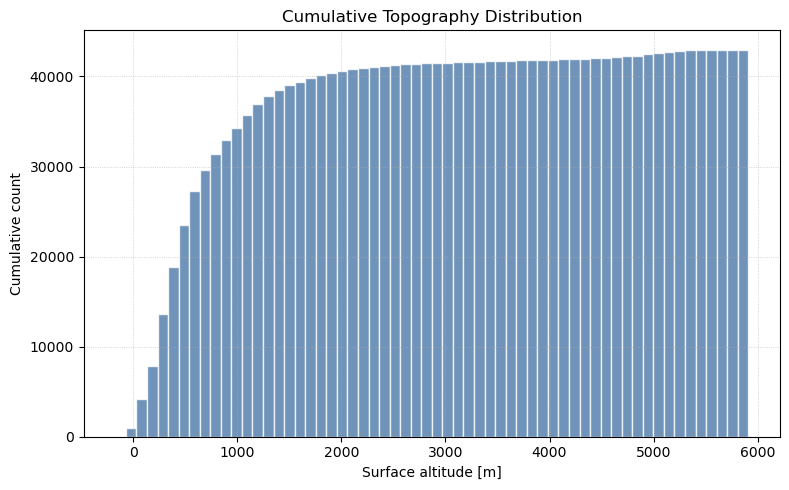

In [ ]:
# Two more examples: 
# Probability density function
fig, ax, _ = plot_topography_histogram(
    data,
    bins=np.arange(-500, 6000, 100),
    density=True,
    title="Topography PDF (100 m bins)"
)

# Cumulative distribution function
fig, ax, _ = plot_topography_histogram(
    data,
    bins=60,
    cumulative=True,
    title="Cumulative Topography Distribution"
)

### Land-use

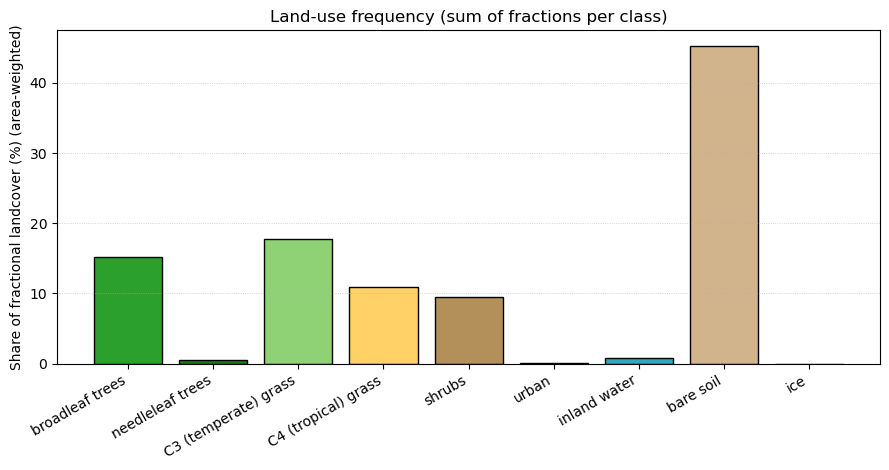

In [ ]:
fig, ax, freq = plot_landuse_frequency(data,
                                        area_weighted=True,
                                       )

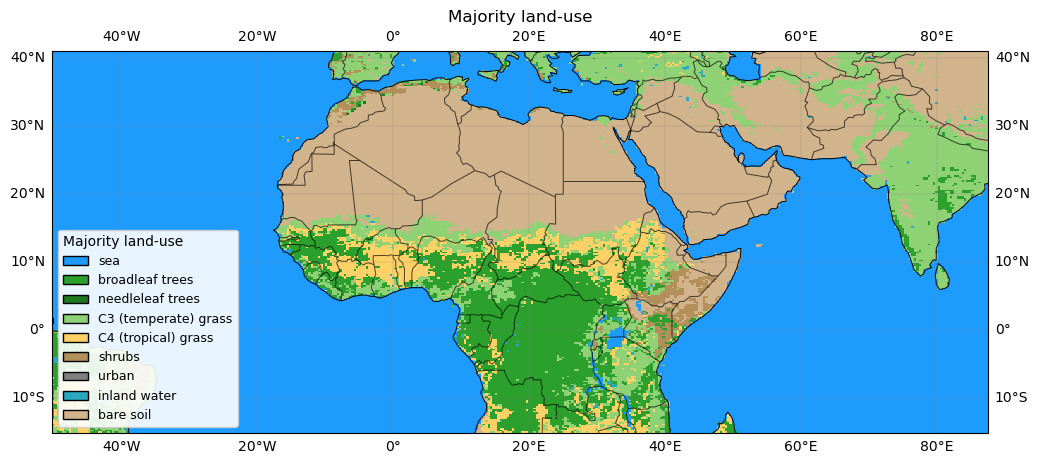

In [ ]:
fig, ax, mesh, majority, (cmap, norm) = plot_majority_landuse_map(
    data,
    title="Majority land‑use"
)

In [ ]:
# To do
# Move default colours stuff from topog_plotting to yaml/config?